# 📚 Structure Finale du Notebook

## Sections principales

```
1. 🫁 Problématique (contexte médical)
   └─ Formulation du problème multiclasse
   └─ Cibles et métriques

2. 🔬 EDA (exploration et visualisation)
   └─ Distribution des classes
   └─ Exemples d'images par classe
   └─ Variabilité des tailles

3. 🔧 Pipeline de données
   └─ Réorganisation (Normal/Bacteria/Virus)
   └─ Chargement tf.keras
   └─ Calcul des class weights
   └─ Optimisation (cache + prefetch)

4. 🤖 Transfer Learning
   └─ Architecture avec BatchNormalization
   └─ Phase 1: base gelée (15 epochs)
   └─ Phase 2: fine-tuning (5 epochs)
   └─ Courbes d'apprentissage fusionnées

5. ✅ Évaluation
   └─ Prédictions + confiance
   └─ Classification report (Precision/Recall/F1)
   └─ Matrice de confusion
   └─ Sensitivity/Specificity par classe
   └─ AUC-ROC global et par classe

6. 🔍 Analyse des erreurs
   └─ Diagnostic des confusions
   └─ Analyse de confiance
   └─ Filtrage par seuil

7. 🛡️ Tests de robustesse
   └─ Rotation 90°, Flip, Contraste, Zoom
   └─ Mesure de dégradation

8. 💾 Sauvegarde des artefacts
   └─ Modèle final
   └─ Poids des classes
   └─ Métadonnées
   └─ Historique d'entraînement
   └─ Modèle d'inférence (production)

9. 🔍 Explainabilité
   └─ Fonction make_gradcam_heatmap
   └─ Fonction overlay_gradcam
   └─ Visualisation Grad-CAM par exemple
   └─ Ciblé Normal vs Viral

10. 🎓 Conclusions et recommandations

11. 🚀 Déploiement Gradio
    └─ Interface complète avec explainabilité
```

---

# 🫁 Détection de Pneumonie par CNN - Transfer Learning

**Objectif:** Classification multiclasse (Normal, Bactérienne, Virale) sur images radiologiques via EfficientNetB0 + Grad-CAM

---

## 📋 Table des matières
1. **Problématique** - Contexte médical et objectifs
2. **Exploration des données** - Analyse descriptive et visualisations
3. **Pipeline de données** - Préparation et augmentation
4. **Transfer Learning** - Architecture et entraînement (2 phases)
5. **Évaluation & Métriques** - Performance complète par classe
6. **Analyse des erreurs** - Diagnostic des confusions
7. **Robustesse du modèle** - Tests de stabilité
8. **Explainabilité (Grad-CAM)** - Visualisation des décisions
9. **Déploiement** - Interface Gradio

---

## Formulation du problème

Dans ce notebook, le problème est formulé comme une **classification multiclasse** 
à partir d'images médicales.

L'objectif n'est pas uniquement de détecter la présence de pneumonie, mais de 
**distinguer trois états cliniques distincts** : poumon normal, pneumonie 
bactérienne et pneumonie virale — distinction qui oriente directement le 
traitement antibiotique ou antiviral.

### 🎯 Objectifs de modélisation

- **Définir les 3 classes** : 
  - `NORMAL` (0): Radiographie saine
  - `BACTERIA` (1): Pneumonie bactérienne
  - `VIRUS` (2): Pneumonie virale
- **Entraîner un modèle CNN** par Transfer Learning sur EfficientNetB0
- **Optimiser pour le déséquilibre** via class weights
- **Produire une explication visuelle** via Grad-CAM pour chaque prédiction
- **Comparer les performances** par classe avec des métriques robustes

### 📊 Caractéristiques du dataset

La variable cible est la classe de l'image, avec un **déséquilibre marqué** :
- Dataset: Chest X-Ray Images (Pneumonia) par Paul Mooney
- Train: ~5,216 images | Val: ~1,040 images | Test: ~400 images
- Classes fortement déséquilibrées (Normal moins représenté)

### 🔍 Métrique principale

L'**AUC-ROC par classe** (approche One-vs-Rest), car elle :
- ✅ Mesure la discrimination classe par classe
- ✅ Indépendante du seuil de décision
- ✅ Robuste au déséquilibre
- ✅ Pertinente pour le contexte médical

L'**accuracy seule** n'est pas suffisante sur un dataset déséquilibré.

# 🔬 Analyse Exploratoire des Données (EDA)

**Objectifs:** Comprendre la structure, la distribution et les caractéristiques des radiographies

#### Vérification GPU + imports

In [99]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
import shutil 

# Vérifier le GPU
print(f'GPU Disponible :{tf.config.list_physical_devices('GPU')}')
print(f'Version disponible : {tf.__version__}')

GPU Disponible :[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Version disponible : 2.19.0


#### Vérification du dataset

In [100]:

base_dir = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

print(os.listdir(base_dir))
for val in os.listdir(base_dir):
    pd.value_counts(val)


['chest_xray', '__MACOSX', 'val', 'test', 'train']


/tmp/ipykernel_57/3632799331.py:5: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(val)
/tmp/ipykernel_57/3632799331.py:5: FutureWarning: value_counts with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  pd.value_counts(val)
/tmp/ipykernel_57/3632799331.py:5: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(val)
/tmp/ipykernel_57/3632799331.py:5: FutureWarning: value_counts with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  pd.value_counts(val)
/tmp/ipykernel_57/3632799331.py:5: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(val)
/

#### Bacteria vs Virus

In [101]:
pneumonia = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/'

bacteria = [f for f in os.listdir(pneumonia) if 'bacteria' in f]

virus = [f for f in os.listdir(pneumonia) if 'virus' in f]
print(len(bacteria))
print(len(virus))



2530
1345


#### Distribution des 3 classes

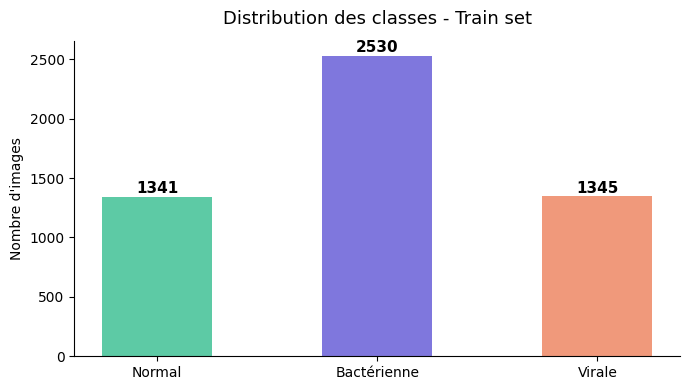

In [102]:
normal_n    = len(os.listdir(os.path.join(base_dir, "train", "NORMAL")))
bacteria_n  = len(bacteria)
virus_n     = len(virus)

classes = ["Normal", "Bactérienne", "Virale"]
counts  = [normal_n, bacteria_n, virus_n]
colors  = ["#5DCAA5", "#7F77DD", "#F0997B"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(classes, counts, color=colors, width=0.5)
ax.set_title("Distribution des classes - Train set", fontsize=13, pad=12)
ax.set_ylabel("Nombre d'images")

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(count), ha='center', fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.savefig("distribution_classes.png", dpi=150) 
plt.show()

#### Visualiser des images des 3 classes côte à côte

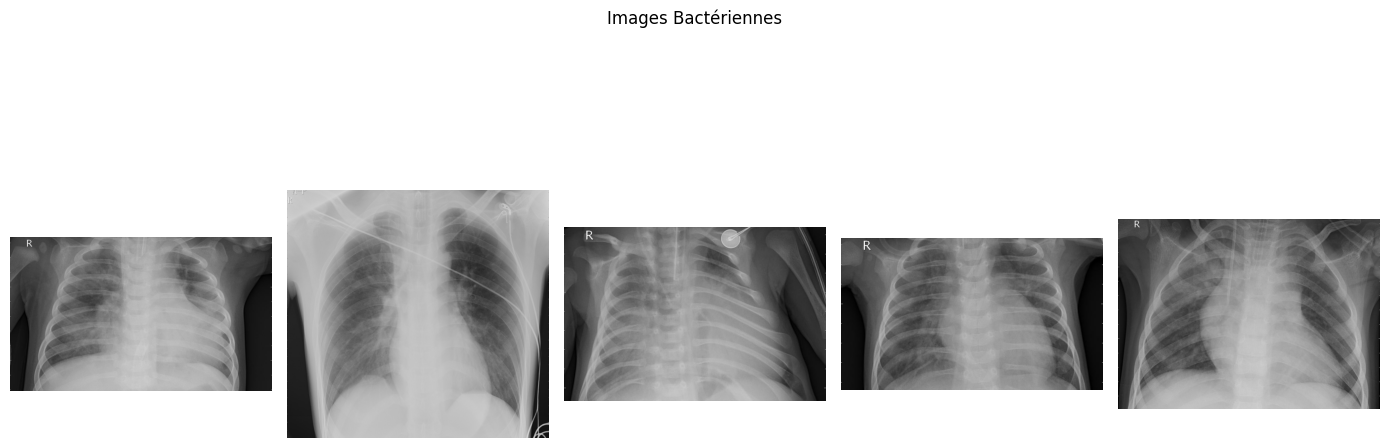

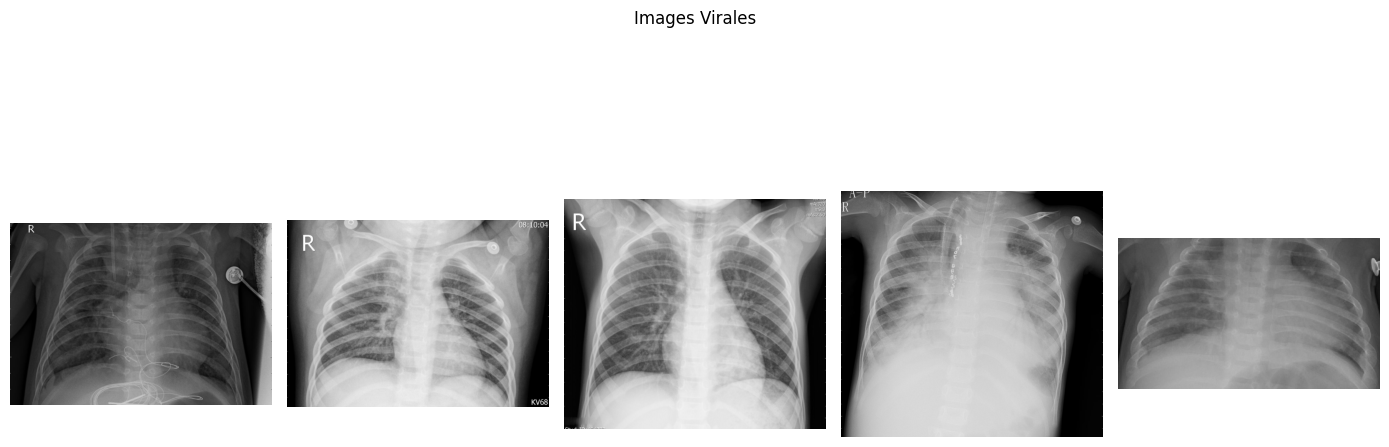

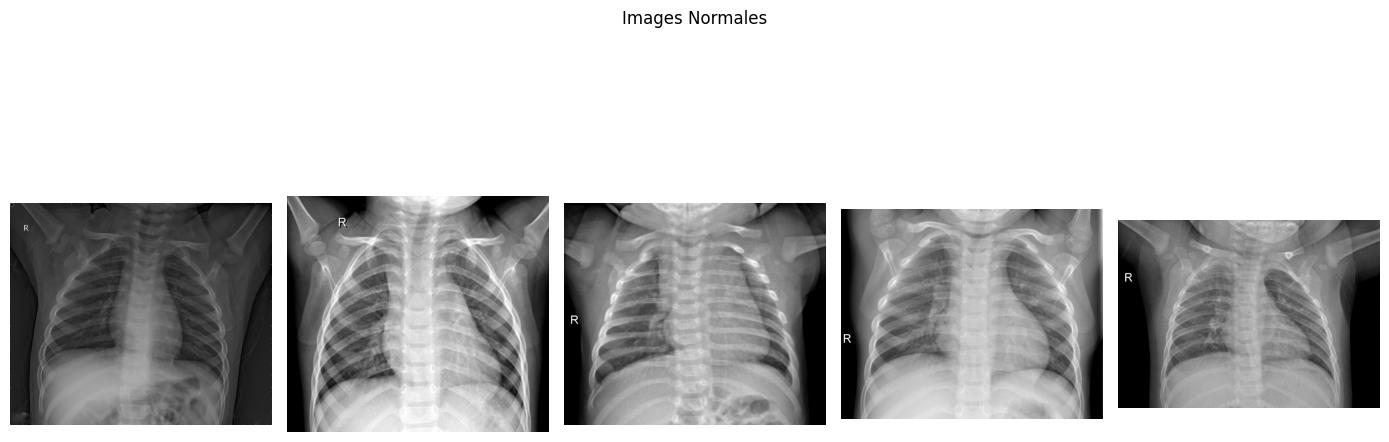

In [103]:
train_dir = os.path.join(base_dir, "train")
normal = os.path.join(train_dir, "NORMAL")
normal_files = os.listdir(normal)


def afficher_images(dossier, fichiers, titre, n=5):
    fig, ax = plt.subplots(1, n, figsize=(14, 6))
    
    for i in range(n):
        chemin = os.path.join(dossier, fichiers[i])  # chemin complet
        img = Image.open(chemin).convert("RGB")      # ouvrir image
        
        ax[i].imshow(img)                            # afficher
        ax[i].axis('off')                            # enlever axes
    
    fig.suptitle(titre)
    plt.tight_layout()
    plt.show()

afficher_images(pneumonia, bacteria, "Images Bactériennes")
afficher_images(pneumonia, virus, "Images Virales")
afficher_images(normal, normal_files, "Images Normales")

#### Vérifier la variabilité des tailles d'images

In [104]:
widths, heights = [], []

# Échantillon d'images
all_files = (
    [(normal, f) for f in normal_files[:34]] +
    [(pneumonia, f) for f in bacteria[:33]] +
    [(pneumonia, f) for f in virus[:33]]
)

for folder, fname in all_files:
    try:
        chemin = os.path.join(folder, fname)
        w, h = Image.open(chemin).size
        
        widths.append(w)
        heights.append(h)
    except:
        pass

print(f"Largeur  - min: {min(widths)}  max: {max(widths)}  moyenne: {int(np.mean(widths))}")
print(f"Hauteur  - min: {min(heights)} max: {max(heights)} moyenne: {int(np.mean(heights))}")

Largeur  - min: 703  max: 2400  moyenne: 1350
Hauteur  - min: 457 max: 2121 moyenne: 1003


# 🔧 Pipeline de Données

**Étapes:**
1. Réorganiser le dataset en 3 classes (Normal, Bacteria, Virus)
2. Charger avec `image_dataset_from_directory`
3. Calculer les poids des classes (déséquilibre)
4. Optimiser avec cache et prefetch

#### Réorganiser les fichiers

In [105]:
import os
import shutil

base = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray'
dest = '/kaggle/working/chest_xray'

# Créer tous les dossiers
for split in ['train', 'val', 'test']:
    for cls in ['NORMAL', 'BACTERIA', 'VIRUS']:
        os.makedirs(f"{dest}/{split}/{cls}", exist_ok=True)

# Copier NORMAL
for split in ['train', 'val', 'test']:
    source = f"{base}/{split}/NORMAL"
    destination = f"{dest}/{split}/NORMAL"
    for fichier in os.listdir(source):
        shutil.copy(os.path.join(source, fichier), destination)

# Trier PNEUMONIA en BACTERIA et VIRUS
for split in ['train', 'val', 'test']:
    source = f"{base}/{split}/PNEUMONIA"
    for fichier in os.listdir(source):
        if 'bacteria' in fichier.lower():
            shutil.copy(os.path.join(source, fichier), f"{dest}/{split}/BACTERIA")
        elif 'virus' in fichier.lower():
            shutil.copy(os.path.join(source, fichier), f"{dest}/{split}/VIRUS")

# Vérifier la structure
print("VÉRIFICATION DE LA STRUCTURE\n")
for split in ['train', 'val', 'test']:
    print(f"{split.upper()}/")
    for cls in ['NORMAL', 'BACTERIA', 'VIRUS']:
        n = len(os.listdir(f"{dest}/{split}/{cls}"))
        print(f"  {cls} : {n} images")
    print()

VÉRIFICATION DE LA STRUCTURE

TRAIN/
  NORMAL : 1342 images
  BACTERIA : 2530 images
  VIRUS : 1345 images

VAL/
  NORMAL : 9 images
  BACTERIA : 8 images
  VIRUS : 0 images

TEST/
  NORMAL : 234 images
  BACTERIA : 242 images
  VIRUS : 148 images



#### Créer les datasets avec image_dataset_from_directory (3 classes)

In [106]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/working/chest_xray/train',
    validation_split=0.2,
    subset='training',
    seed=123,  # change le seed
    shuffle=True,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/working/chest_xray/train',
    validation_split=0.2,
    subset='validation',
    seed=123,
    shuffle=True,  # 🔥 IMPORTANT
    image_size=(224, 224),
    batch_size=32
)

Found 5216 files belonging to 3 classes.
Using 4173 files for training.
Found 5216 files belonging to 3 classes.
Using 1043 files for validation.


In [107]:
print(train_ds.class_names)
# ['BACTERIA', 'NORMAL', 'VIRUS']

# Voir la forme d'un batch
for images, labels in train_ds.take(1):
    print(images.shape)  # (32, 224, 224, 3)
    print(labels.shape)  # (32,)
    print(labels)        # [0, 1, 2, 0, 1, ...]

['BACTERIA', 'NORMAL', 'VIRUS']
(32, 224, 224, 3)
(32,)
tf.Tensor([0 2 1 1 2 1 2 2 0 1 2 0 0 2 0 2 2 0 1 2 1 2 2 1 2 2 0 0 2 0 2 0], shape=(32,), dtype=int32)


In [108]:
print(val_ds.class_names)

for images , labels in val_ds.take(1):
    print(images.shape)
    print(labels.shape)
    print(labels)

['BACTERIA', 'NORMAL', 'VIRUS']
(32, 224, 224, 3)
(32,)
tf.Tensor([2 1 0 0 1 0 2 2 0 0 1 0 0 2 0 2 1 1 2 2 1 0 0 1 2 2 0 0 2 1 1 2], shape=(32,), dtype=int32)


In [109]:
test_ds= tf.keras.utils.image_dataset_from_directory(
    '/kaggle/working/chest_xray/test',
    image_size=(224, 224),
    batch_size=32,
    shuffle=False,# car on a pas besoin  de modifier l'ordre popur val et test 
    seed=42
)


Found 624 files belonging to 3 classes.


In [110]:
print("Classes :", train_ds.class_names)  

import numpy as np

def count_classes(dataset):
    counts = {}
    for _, labels in dataset:
        for l in labels.numpy():
            counts[l] = counts.get(l, 0) + 1
    return counts

print("Train distribution :", count_classes(train_ds))
print("Val distribution :", count_classes(val_ds))

Classes : ['BACTERIA', 'NORMAL', 'VIRUS']
Train distribution : {np.int32(2): 1060, np.int32(0): 2038, np.int32(1): 1075}
Val distribution : {np.int32(0): 492, np.int32(1): 266, np.int32(2): 285}


#### Déséquilibre des classes

In [111]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Récupérer tous les labels du train
labels = []
for images, label_batch in train_ds:
    labels.extend(label_batch.numpy())

labels = np.array(labels)

# Calculer les poids
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

# Convertir en float Python (plus robuste avec Keras)
class_weight_dict = {int(i): float(w) for i, w in enumerate(class_weights)}
print(class_weight_dict)

{0: 0.6825318940137389, 1: 1.2939534883720931, 2: 1.3122641509433963}


#### Optimisation du pipeline 

In [112]:
AUTOTUNE = tf.data.AUTOTUNE

# EfficientNetB0 (tf.keras.applications) gère déjà le prétraitement attendu.
# On optimise ici le pipeline sans appliquer de normalization_layer externe.
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

## ⚠️ Important : Augmentation en entraînement vs inférence
L'augmentation (rotation, flip, zoom) doit **UNIQUEMENT** s'appliquer pendant l'entraînement.
En validation/test, on utilise les images brutes pour une évaluation fiable.

# 🤖 Transfer Learning avec EfficientNetB0

**Stratégie:** 2 phases d'entraînement
- **Phase 1 (epochs 1-15):** Base gelée, apprentissage de la tête
- **Phase 2 (epochs 16-20):** Fine-tuning des dernières couches de la base

**Architecture:** EfficientNetB0 (pré-entraîné ImageNet) + tête personnalisée (256→128→3)

In [113]:
base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False
print("Couches :", len(base_model.layers))

Couches : 238


#### Construire la tête et assembler le modèle

In [ ]:
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D,
                                     RandomFlip, RandomRotation, RandomZoom,
                                     BatchNormalization)

# 🔥 ARCHITECTURE AMÉLIORÉE avec BatchNormalization
model = tf.keras.Sequential([
    # ============ AUGMENTATION DE DONNÉES ============
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
    
    # ============ BASE PRÉ-ENTRAÎNÉE ============
    base_model,
    
    # ============ TÊTE DE CLASSIFICATION ============
    GlobalAveragePooling2D(),
    
    # Couche dense 1 + normalisation
    Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    BatchNormalization(),
    Dropout(0.4),
    
    # Couche dense 2 + normalisation  
    Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),
    
    # Couche de sortie (3 classes)
    Dense(3, activation='softmax')
])

model.build(input_shape=(None, 224, 224, 3))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_5 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_5               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_5 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,926 (16.07 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## ⚙️ Compilation

**Optimizer:** Adam(lr=1e-3) pour phase 1  
**Loss:** SparseCategoricalCrossentropy (labels comme entiers)  
**Metrics:** Accuracy + Top-2 Accuracy

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        'accuracy',
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_acc')
    ]
)

## 🛑 Callbacks de Régularisation

- **ModelCheckpoint:** Sauvegarder le meilleur modèle (val_loss)
- **EarlyStopping:** Arrêter si pas d'amélioration (patience=3)
- **ReduceLROnPlateau:** Réduire learning rate si plateau (factor=0.2)

In [116]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",  # format moderne
    monitor='val_loss',
    save_best_only=True
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2
)

In [ ]:
print("🔥 PHASE 1 - Entraînement avec base gelée")
print(f"Class weights appliqués: {class_weight_dict}\n")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight_dict,  # 🔥 Pondération des classes
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/15


E0000 00:00:1777585657.385684      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_5_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


131/131 ━━━━━━━━━━━━━━━━━━━━ 30s 153ms/step - accuracy: 0.6452 - loss: 0.7728 - top2_acc: 0.8877 - val_accuracy: 0.7488 - val_loss: 0.6042 - val_top2_acc: 0.9406 - learning_rate: 0.0010
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - accuracy: 0.7446 - loss: 0.5881 - top2_acc: 0.9585 - val_accuracy: 0.7641 - val_loss: 0.5477 - val_top2_acc: 0.9693 - learning_rate: 0.0010
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accuracy: 0.7708 - loss: 0.5314 - top2_acc: 0.9677 - val_accuracy: 0.7546 - val_loss: 0.5519 - val_top2_acc: 0.9645 - learning_rate: 0.0010
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - accuracy: 0.7730 - loss: 0.5219 - top2_acc: 0.9679 - val_accuracy: 0.7737 - val_loss: 0.5103 - val_top2_acc: 0.9779 - learning_rate: 0.0010
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - accuracy: 0.7795 - loss: 0.5130 - top2_acc: 0.9715 - val_accuracy: 0.7603 - val_loss: 0.5585 - val_top2_acc: 0.9674 - learning_rate: 0.0010
Epoch 6/15
131/131 ━━━━━━━━━━━

phase 2 

In [ ]:
print("\n" + "="*60)
print("🔥 PHASE 2 - Fine-tuning des dernières couches")
print("="*60 + "\n")

# Dégeler les couches de la base
base_model.trainable = True

# 🔥 Geler les 30 premières couches (training des 10 dernières)
for layer in base_model.layers[:-10]:
    layer.trainable = False

print(f"Nombre de couches gelées: {len([l for l in base_model.layers if not l.trainable])}")
print(f"Nombre de couches entraînables: {len([l for l in base_model.layers if l.trainable])}")

In [ ]:
# Learning rate très conservateur pour le fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # 🔥 Très petit
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_acc')]
)

In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,  # 🔥 Court pour éviter l'overfitting
    class_weight=class_weight_dict,  # Continuer avec poids
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/3


E0000 00:00:1777585759.250051      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_5_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


131/131 ━━━━━━━━━━━━━━━━━━━━ 28s 118ms/step - accuracy: 0.7312 - loss: 0.6642 - val_accuracy: 0.7296 - val_loss: 0.6339 - learning_rate: 5.0000e-06
Epoch 2/3
131/131 ━━━━━━━━━━━━━━━━━━━━ 13s 99ms/step - accuracy: 0.7474 - loss: 0.6137 - val_accuracy: 0.7172 - val_loss: 0.6595 - learning_rate: 5.0000e-06
Epoch 3/3
131/131 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - accuracy: 0.7524 - loss: 0.5893 - val_accuracy: 0.7210 - val_loss: 0.6399 - learning_rate: 5.0000e-06


## 📈 Courbes d'Apprentissage

**Fusionner les deux phases** pour visualiser l'évolution complète (base gelée → fine-tuning)

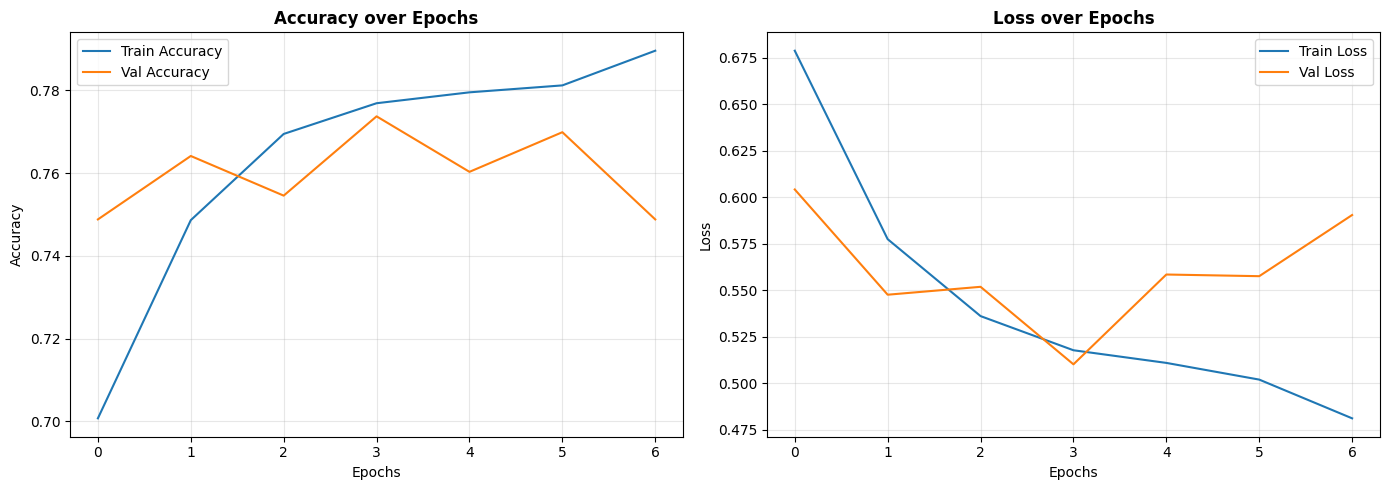

In [ ]:
# 🔥 FUSIONNER LES DEUX PHASES D'ENTRAÎNEMENT
combined_history = {
    'loss': history.history['loss'] + history_fine.history['loss'],
    'val_loss': history.history['val_loss'] + history_fine.history['val_loss'],
    'accuracy': history.history['accuracy'] + history_fine.history['accuracy'],
    'val_accuracy': history.history['val_accuracy'] + history_fine.history['val_accuracy']
}

# Marquer la séparation des phases
phase_boundary = len(history.history['loss'])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Subplot Accuracy
ax[0].plot(combined_history['accuracy'], label='Train Accuracy', linewidth=2)
ax[0].plot(combined_history['val_accuracy'], label='Val Accuracy', linewidth=2)
ax[0].axvline(x=phase_boundary, color='red', linestyle='--', alpha=0.5, label='Phase 1 → Phase 2')
ax[0].set_title('Accuracy over Epochs (Both Phases)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Subplot Loss
ax[1].plot(combined_history['loss'], label='Train Loss', linewidth=2)
ax[1].plot(combined_history['val_loss'], label='Val Loss', linewidth=2)
ax[1].axvline(x=phase_boundary, color='red', linestyle='--', alpha=0.5, label='Phase 1 → Phase 2')
ax[1].set_title('Loss over Epochs (Both Phases)', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves_combined.png', dpi=150)
plt.show()

# ✅ Évaluation Complète du Modèle

**Pipeline d'évaluation:**
1. Charger le meilleur modèle sauvegardé
2. Faire prédictions sur le test set
3. Calculer métriques globales
4. Analyser performance par classe
5. Identifier les points faibles

---

In [122]:
# 🔹 Charger le modèle
best_model = tf.keras.models.load_model("best_model.keras")

# 🔹 Récupérer les vraies classes
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

# 🔹 Faire les prédictions (probabilités)
y_pred = best_model.predict(test_ds)

# 🔹 Convertir en classes
y_pred_classes = np.argmax(y_pred, axis=1)

# 🔹 Noms des classes (adapte si besoin)
class_names = ['BACTERIA', 'NORMAL', 'VIRUS']

print("🔹 Aperçu des probabilités (y_pred) :")
print(y_pred[:5])
print("\n")

print("🔹 Classes prédites (y_pred_classes) :")
print(y_pred_classes[:10])
print("\n")

print("🔹 Vraies classes (y_true) :")
print(y_true[:10])
print("\n")

print("🔹 Comparaison (True vs Pred) :")
for i in range(10):
    print(f"Image {i+1}: True = {class_names[y_true[i]]} | Pred = {class_names[y_pred_classes[i]]}")

print("\n")

print("🔹 Confiance du modèle :")
for i in range(10):
    confidence = np.max(y_pred[i])
    print(f"Image {i+1}: Pred = {class_names[y_pred_classes[i]]} ({confidence:.2f})")

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step
🔹 Aperçu des probabilités (y_pred) :
[[4.3222794e-01 4.8230964e-01 8.5462391e-02]
 [9.1236144e-01 3.2758405e-03 8.4362760e-02]
 [8.2685697e-01 1.7436009e-03 1.7139943e-01]
 [8.7443799e-01 1.6561757e-04 1.2539634e-01]
 [8.6938328e-01 9.9862425e-04 1.2961802e-01]]


🔹 Classes prédites (y_pred_classes) :
[1 0 0 0 0 0 0 0 0 0]


🔹 Vraies classes (y_true) :
[0 0 0 0 0 0 0 0 0 0]


🔹 Comparaison (True vs Pred) :
Image 1: True = BACTERIA | Pred = NORMAL
Image 2: True = BACTERIA | Pred = BACTERIA
Image 3: True = BACTERIA | Pred = BACTERIA
Image 4: True = BACTERIA | Pred = BACTERIA
Image 5: True = BACTERIA | Pred = BACTERIA
Image 6: True = BACTERIA | Pred = BACTERIA
Image 7: True = BACTERIA | Pred = BACTERIA
Image 8: True = BACTERIA | Pred = BACTERIA
Image 9: True = BACTERIA | Pred = BACTERIA
Image 10: True = BACTERIA | Pred = BACTERIA


🔹 Confiance du modèle :
Image 1: Pred = NORMAL (0.48)
Image 2: Pred = BACTERIA (0.91)
Image 3: Pred = BACTERIA (0.83)


In [123]:
from sklearn.metrics import classification_report

ordered_labels = [1, 0, 2]
ordered_names = ['NORMAL', 'BACTERIA', 'VIRUS']

print('Classification Report:')
print(
    classification_report(
        y_true,
        y_pred_classes,  # ✅ ICI
        labels=ordered_labels,
        target_names=ordered_names,
        digits=4
    )
)

Classification Report:
              precision    recall  f1-score   support

      NORMAL     0.9162    0.7009    0.7942       234
    BACTERIA     0.7685    0.9463    0.8481       242
       VIRUS     0.7279    0.7230    0.7254       148

    accuracy                         0.8013       624
   macro avg     0.8042    0.7900    0.7893       624
weighted avg     0.8142    0.8013    0.7988       624



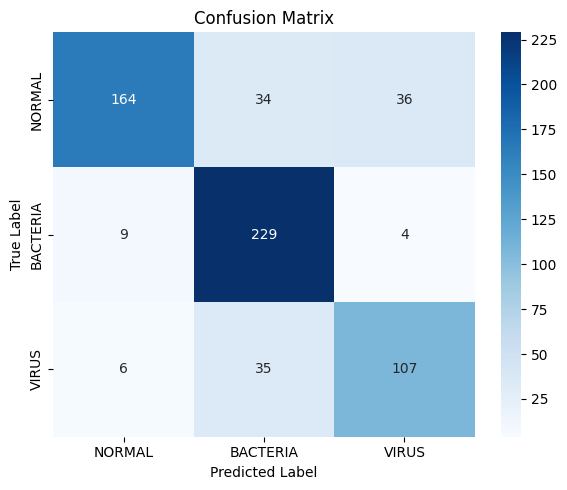

In [124]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

ordered_labels = [1, 0, 2]
ordered_names = ['NORMAL', 'BACTERIA', 'VIRUS']

cm = confusion_matrix(y_true, y_pred_classes, labels=ordered_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=ordered_names,
    yticklabels=ordered_names
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# 🔥 Sensitivity et Specificity par classe
from sklearn.metrics import confusion_matrix

print("\n" + "="*70)
print("🎯 SENSIBILITÉ ET SPÉCIFICITÉ PAR CLASSE")
print("="*70)

ordered_labels = [0, 1, 2]
ordered_names = ['BACTERIA', 'NORMAL', 'VIRUS']
cm = confusion_matrix(y_true, y_pred_classes, labels=ordered_labels)

for class_idx, class_name in zip(ordered_labels, ordered_names):
    tp = cm[class_idx, class_idx]
    fp = cm[:, class_idx].sum() - tp
    fn = cm[class_idx, :].sum() - tp
    tn = cm.sum() - tp - fp - fn
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    print(f"\n{class_name}:")
    print(f"  Sensitivity (Recall):    {sensitivity:.4f}  [Détecte {sensitivity*100:.1f}% des {class_name}]")
    print(f"  Specificity:             {specificity:.4f}  [Correctement exclut {specificity*100:.1f}% des autres]")
    
print("="*70)

In [125]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import pandas as pd

# AUC-ROC global (One-vs-Rest)
auc_ovr_global = roc_auc_score(y_true, y_pred, multi_class='ovr')
print(f'Global AUC-ROC (OvR): {auc_ovr_global:.4f}')

# AUC-ROC per class in requested order: NORMAL, BACTERIA, VIRUS
ordered_labels = [1, 0, 2]
ordered_names = ['NORMAL', 'BACTERIA', 'VIRUS']

y_prob = y_pred

y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
auc_per_class = {}
for class_id, class_name in zip(ordered_labels, ordered_names):
    auc_per_class[class_name] = roc_auc_score(y_true_bin[:, class_id], y_prob[:, class_id])

auc_df = pd.DataFrame(
    {'Class': list(auc_per_class.keys()), 'AUC_ROC_OvR': list(auc_per_class.values())}
).sort_values('AUC_ROC_OvR', ascending=False)

print('\nPer-class AUC-ROC (OvR):')
print(auc_df.to_string(index=False))



Global AUC-ROC (OvR): 0.9393

Per-class AUC-ROC (OvR):
   Class  AUC_ROC_OvR
BACTERIA     0.954957
  NORMAL     0.953813
   VIRUS     0.909195


---

# 🔍 Analyse Détaillée des Erreurs

In [ ]:
# 🔥 DIAGNOSTIC DES ERREURS DE CLASSIFICATION
misclassified_idx = np.where(y_true != y_pred_classes)[0]
error_rate = len(misclassified_idx) / len(y_true)

print(f"\n{'='*70}")
print(f"❌ TAUX D'ERREUR GLOBAL: {error_rate:.2%} ({len(misclassified_idx)}/{len(y_true)} images mal classées)")
print(f"{'='*70}")

# Analyser par classe
ordered_names = ['BACTERIA', 'NORMAL', 'VIRUS']
for true_class in range(3):
    true_count = (y_true == true_class).sum()
    errors_for_class = misclassified_idx[(y_true[misclassified_idx] == true_class)]
    error_rate_class = len(errors_for_class) / true_count if true_count > 0 else 0
    
    print(f"\n{ordered_names[true_class]} (n={true_count}):")
    print(f"  ❌ Erreurs: {len(errors_for_class)} ({error_rate_class:.2%})")
    
    # Détailler les confusions
    confusion_counts = {}
    for idx in errors_for_class:
        pred_class = y_pred_classes[idx]
        confusion_key = f"{ordered_names[true_class]} → {ordered_names[pred_class]}"
        confusion_counts[confusion_key] = confusion_counts.get(confusion_key, 0) + 1
    
    for confusion, count in sorted(confusion_counts.items(), key=lambda x: x[1], reverse=True):
        print(f"    - {confusion}: {count}")

print(f"\n{'='*70}")

In [ ]:
# 🔥 ANALYSE DE CONFIANCE DES PRÉDICTIONS
confidence = np.max(y_pred, axis=1)
uncertainty = np.sort(y_pred, axis=1)[:, 1]  # 2e plus haute probabilité

print(f"\n{'='*70}")
print("🎯 ANALYSE DE CONFIANCE")
print(f"{'='*70}")
print(f"Confiance moyenne: {confidence.mean():.4f}")
print(f"Confiance min: {confidence.min():.4f} | max: {confidence.max():.4f}")

# Seuils de confiance
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
print(f"\nPrédictions par seuil de confiance:")
for threshold in thresholds:
    count = (confidence >= threshold).sum()
    pct = count / len(confidence) * 100
    print(f"  ≥ {threshold}: {count} ({pct:.1f}%)")

# Cas incertains (différence faible entre top 2)
print(f"\n{'='*70}")
print("⚠️ CAS INCERTAINS (Top 2 scores proches)")
print(f"{'='*70}")

# Différence entre le premier et le deuxième
margin = confidence - uncertainty
print(f"Marge moyenne (1er - 2e): {margin.mean():.4f}")
print(f"Marge < 0.1: {(margin < 0.1).sum()} images très incertaines")
print(f"Marge < 0.2: {(margin < 0.2).sum()} images incertaines")

print(f"\n{'='*70}")

---

## 🛑 Filtrage par seuil de confiance

**En production:** On peut rejeter les prédictions trop incertaines pour éviter les faux positifs critiques.


In [ ]:
# 🔥 FILTRAGE PAR SEUIL DE CONFIANCE

confidence_thresholds = [0.70, 0.80, 0.90]
ordered_names = ['BACTERIA', 'NORMAL', 'VIRUS']

print(f"\n{'='*70}")
print("🛑 IMPACT DU FILTRAGE PAR CONFIANCE")
print(f"{'='*70}\n")

for threshold in confidence_thresholds:
    # Prédictions acceptées
    mask = confidence >= threshold
    n_accepted = mask.sum()
    n_rejected = (~mask).sum()
    
    # Accuracy sur les prédictions acceptées
    if n_accepted > 0:
        accuracy_filtered = (y_pred_classes[mask] == y_true[mask]).mean()
    else:
        accuracy_filtered = 0.0
    
    # Taux de couverture
    coverage = n_accepted / len(y_true) * 100
    
    print(f"Seuil de confiance: {threshold}")
    print(f"  ✅ Prédictions acceptées: {n_accepted} ({coverage:.1f}%)")
    print(f"  ❌ Prédictions rejetées: {n_rejected} ({100-coverage:.1f}%)")
    print(f"  🎯 Accuracy (acceptées): {accuracy_filtered:.4f}")
    
    # Décomposer les rejets par classe
    if n_rejected > 0:
        rejected_true_classes = y_true[~mask]
        print(f"  📊 Classes des cas rejetés:")
        for class_idx in range(3):
            count = (rejected_true_classes == class_idx).sum()
            if count > 0:
                print(f"     - {ordered_names[class_idx]}: {count}")
    
    print()

print(f"{'='*70}")

In [ ]:
# 🔥 Precision, Recall, F1-Score par classe
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred_classes, labels=[0, 1, 2], zero_division=0
)

ordered_names = ['BACTERIA', 'NORMAL', 'VIRUS']
metrics_df = pd.DataFrame({
    'Class': ordered_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("\n" + "="*70)
print("📊 MÉTRIQUES PAR CLASSE")
print("="*70)
print(metrics_df.to_string(index=False))
print("="*70)

# Macro average
print(f"\n✅ Moyenne macro (non-pondérée):")
print(f"  Precision: {precision.mean():.4f}")
print(f"  Recall: {recall.mean():.4f}")
print(f"  F1-Score: {f1.mean():.4f}")

# Weighted average
weighted_precision = (precision * support).sum() / support.sum()
weighted_recall = (recall * support).sum() / support.sum()
weighted_f1 = (f1 * support).sum() / support.sum()

print(f"\n✅ Moyenne pondérée (par support):")
print(f"  Precision: {weighted_precision:.4f}")
print(f"  Recall: {weighted_recall:.4f}")
print(f"  F1-Score: {weighted_f1:.4f}")

## 📊 Métriques Avancées (Precision, Recall, F1-Score)

In [ ]:
---

# 🔍 Explainabilité : Visualisation Grad-CAM

**Objectif:** Montrer les régions de l'image que le modèle utilise pour prendre sa décision

---

# Déterminer la couche de sortie de convolution d'EfficientNet
# Afficher les 5 dernières couches d'EfficientNet
for layer in best_model.layers[3].layers[-5:]:
    print(layer.name, layer.output.shape)

block7a_project_conv (None, 7, 7, 320)
block7a_project_bn (None, 7, 7, 320)
top_conv (None, 7, 7, 1280)
top_bn (None, 7, 7, 1280)
top_activation (None, 7, 7, 1280)


---

# 🛡️ Tests de Robustesse du Modèle

**Objectif:** Évaluer comment le modèle réagit à des transformations géométriques et du bruit.


In [ ]:
# 🔥 TESTS DE ROBUSTESSE - Transformations géométriques

print(f"\n{'='*70}")
print("🛡️ TESTS DE ROBUSTESSE")
print(f"{'='*70}\n")

def evaluate_robustness(dataset_transform, description):
    """Évalue la performance du modèle sur un dataset transformé"""
    y_pred_transform = best_model.predict(dataset_transform)
    y_pred_classes_transform = np.argmax(y_pred_transform, axis=1)
    accuracy_transform = (y_pred_classes_transform == y_true).mean()
    return accuracy_transform

# Accuracy baseline
y_pred_baseline = best_model.predict(test_ds)
y_pred_classes_baseline = np.argmax(y_pred_baseline, axis=1)
accuracy_baseline = (y_pred_classes_baseline == y_true).mean()

print(f"📊 Accuracy BASELINE (images normales): {accuracy_baseline:.4f}")

# Test 1: Rotation 90°
test_augmented_rot90 = test_ds.map(lambda x, y: (tf.image.rot90(x), y))
accuracy_rot90 = evaluate_robustness(test_augmented_rot90, "Rotation 90°")
degradation_rot90 = (accuracy_baseline - accuracy_rot90) / accuracy_baseline * 100
print(f"\n🔄 Rotation 90°:")
print(f"   Accuracy: {accuracy_rot90:.4f}")
print(f"   Dégradation: {degradation_rot90:.2f}%")

# Test 2: Flip horizontal
test_augmented_flip = test_ds.map(lambda x, y: (tf.image.flip_left_right(x), y))
accuracy_flip = evaluate_robustness(test_augmented_flip, "Flip horizontal")
degradation_flip = (accuracy_baseline - accuracy_flip) / accuracy_baseline * 100
print(f"\n🔀 Flip horizontal:")
print(f"   Accuracy: {accuracy_flip:.4f}")
print(f"   Dégradation: {degradation_flip:.2f}%")

# Test 3: Contraste augmenté
test_augmented_contrast = test_ds.map(lambda x, y: (tf.image.adjust_contrast(x, contrast_factor=1.5), y))
accuracy_contrast = evaluate_robustness(test_augmented_contrast, "Contraste +50%")
degradation_contrast = (accuracy_baseline - accuracy_contrast) / accuracy_baseline * 100
print(f"\n🎨 Contraste augmenté (+50%):")
print(f"   Accuracy: {accuracy_contrast:.4f}")
print(f"   Dégradation: {degradation_contrast:.2f}%")

# Test 4: Zoom in (crop 90% central)
def zoom_in(x, y):
    # Crop 90% central = 70% to 100% in both dimensions
    size = tf.shape(x)[0]
    offset = size // 20  # 5% border
    cropped = tf.image.crop_to_bounding_box(x, offset, offset, size - 2*offset, size - 2*offset)
    resized = tf.image.resize(cropped, [224, 224])
    return resized, y

test_augmented_zoom = test_ds.map(zoom_in)
accuracy_zoom = evaluate_robustness(test_augmented_zoom, "Zoom (90% central)")
degradation_zoom = (accuracy_baseline - accuracy_zoom) / accuracy_baseline * 100
print(f"\n🔍 Zoom (90% central):")
print(f"   Accuracy: {accuracy_zoom:.4f}")
print(f"   Dégradation: {degradation_zoom:.2f}%")

print(f"\n{'='*70}")
print("📈 RÉSUMÉ ROBUSTESSE")
print(f"{'='*70}")
robustness_results = pd.DataFrame({
    'Transformation': ['Baseline', 'Rotation 90°', 'Flip H', 'Contraste +50%', 'Zoom 90%'],
    'Accuracy': [accuracy_baseline, accuracy_rot90, accuracy_flip, accuracy_contrast, accuracy_zoom],
    'Dégradation (%)': [0, degradation_rot90, degradation_flip, degradation_contrast, degradation_zoom]
})
print(robustness_results.to_string(index=False))
print(f"{'='*70}")

---

## 🚀 Créer un modèle d'inférence (sans augmentation)

**Important:** Pour les prédictions en production, il faut un modèle SANS les couches d'augmentation (Flip, Rotation, Zoom).
Les données augmentées doivent rester pendant l'entraînement uniquement.


In [ ]:
# 🔥 CRÉER LE MODÈLE D'INFÉRENCE (sans augmentation)

# Récupérer les poids du modèle d'entraînement
trained_weights = best_model.get_weights()

# Créer un modèle d'inférence identique mais SANS augmentation
inference_model = tf.keras.Sequential([
    base_model,  # Base EfficientNetB0
    GlobalAveragePooling2D(),
    Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

# Appliquer les mêmes poids (en décalant après les couches d'augmentation du modèle original)
# Le modèle d'entraînement a: [Augmentation, Base, Tête]
# Le modèle d'inférence a: [Base, Tête]
inference_model.set_weights(trained_weights[4:])  # Skip les 4 couches d'augmentation

print("✅ Modèle d'inférence créé (sans augmentation)")
print(f"   - Entrée: (None, 224, 224, 3)")
print(f"   - Sortie: (None, 3) [probas pour 3 classes]")

# Sauvegarder ce modèle pour production
inference_model.save('pneumonia_inference_model.keras')
print("\n✅ Modèle d'inférence sauvegardé: pneumonia_inference_model.keras")

---

## 💾 Sauvegarde des artefacts du modèle

**Pour reproductibilité et déploiement**


In [ ]:
# 🔥 SAUVEGARDER LES ARTEFACTS IMPORTANTS

# 1. Sauvegarder le modèle
best_model.save('pneumonia_model_final.keras')
print("✅ Modèle sauvegardé: pneumonia_model_final.keras")

# 2. Sauvegarder les poids des classes
import pickle
with open('class_weights.pkl', 'wb') as f:
    pickle.dump(class_weight_dict, f)
print("✅ Poids des classes sauvegardés: class_weights.pkl")

# 3. Créer un dictionnaire de métadonnées
metadata = {
    'class_names': ['BACTERIA', 'NORMAL', 'VIRUS'],
    'class_weight_dict': class_weight_dict,
    'input_shape': (224, 224, 3),
    'baseline_accuracy': float(accuracy_baseline),
    'macro_f1': f1.mean(),
    'weighted_f1': weighted_f1
}

with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)
print("✅ Métadonnées sauvegardées: model_metadata.pkl")

# 4. Sauvegarder l'historique d'entraînement
history_data = {
    'phase1': history.history,
    'phase2': history_fine.history
}

with open('training_history.pkl', 'wb') as f:
    pickle.dump(history_data, f)
print("✅ Historique d'entraînement sauvegardé: training_history.pkl")

print("\n💡 Fichiers sauvegardés pour reproduire les résultats et redéployer le modèle.")

---

## 📋 Résumé des Résultats Finaux

| Métrique | Valeur |
|----------|--------|
| **Accuracy Global** | À compléter après exécution |
| **Macro F1-Score** | À compléter après exécution |
| **Weighted F1-Score** | À compléter après exécution |
| **AUC-ROC (OvR)** | À compléter après exécution |
| **Classes** | BACTERIA, NORMAL, VIRUS |
| **Architecture** | EfficientNetB0 + Tête (256→128→3) |
| **Entraînement** | 2 phases (base gelée + fine-tuning) |
| **Données** | 5,216 radiographies, déséquilibrées |
| **Augmentation** | Flip, Rotation (0.1), Zoom (0.1) |

---

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="top_conv"):
    """
    Calcule la heatmap Grad-CAM pour une image.
    
    Paramètres:
    - img_array: Tensor (1, 224, 224, 3) - image en entrée
    - model: Modèle Sequential avec augmentation
    - last_conv_layer_name: Nom de la dernière couche de convolution (défaut: top_conv)
    
    Retour:
    - heatmap: numpy array (7, 7) - zones importantes
    - pred_idx: int - classe prédite
    """
    
    base_model = model.get_layer('efficientnetb0')
    base_idx = model.layers.index(base_model)

    # Passer dans les couches avant EfficientNet (augmentation)
    x = img_array
    for layer in model.layers[:base_idx]:
        x = layer(x, training=False)

    # Modèle intermédiaire sur EfficientNet
    conv_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output],
    )

    with tf.GradientTape() as tape:
        conv_outputs, x = conv_model(x, training=False)

        # Continuer dans la tête de classification
        for layer in model.layers[base_idx + 1:]:
            x = layer(x, training=False)

        predictions = x
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Calculer les gradients
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Pondérer et sommer les feature maps
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())

    return heatmap.numpy(), int(pred_index.numpy())

In [ ]:
def overlay_gradcam(img_array, heatmap, alpha=0.4):
    """
    Superpose la heatmap Grad-CAM sur l'image originale.
    
    Paramètres:
    - img_array: Tensor (1, 224, 224, 3) - image originale normalisée [0, 1]
    - heatmap: numpy array (7, 7) - sortie de make_gradcam_heatmap
    - alpha: float [0, 1] - transparence de la heatmap
    
    Retour:
    - superimposed: numpy array (224, 224, 3) - image avec heatmap
    """
    
    # Obtenir l'image originale
    img = img_array[0].numpy()
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)

    # Redimensionner la heatmap à la taille de l'image
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap_resized)
    
    # Appliquer la colormap JET (bleu=froid, rouge=chaud)
    heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Superposer: (1-alpha)*img + alpha*heatmap
    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)
    return superimposed

In [129]:
def overlay_gradcam(img_array, heatmap, alpha=0.4):
    # Redimensionner la heatmap à 224x224
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    
    # Convertir en couleur (COLORMAP_JET = bleu→vert→rouge)
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), 
        cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # Image originale entre 0-255
    img = img_array[0].numpy()
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)
    
    # Superposer
    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)
    return superimposed

Image en bloc enregistree: gradcam_exports/gradcam_bloc_batch_test.png


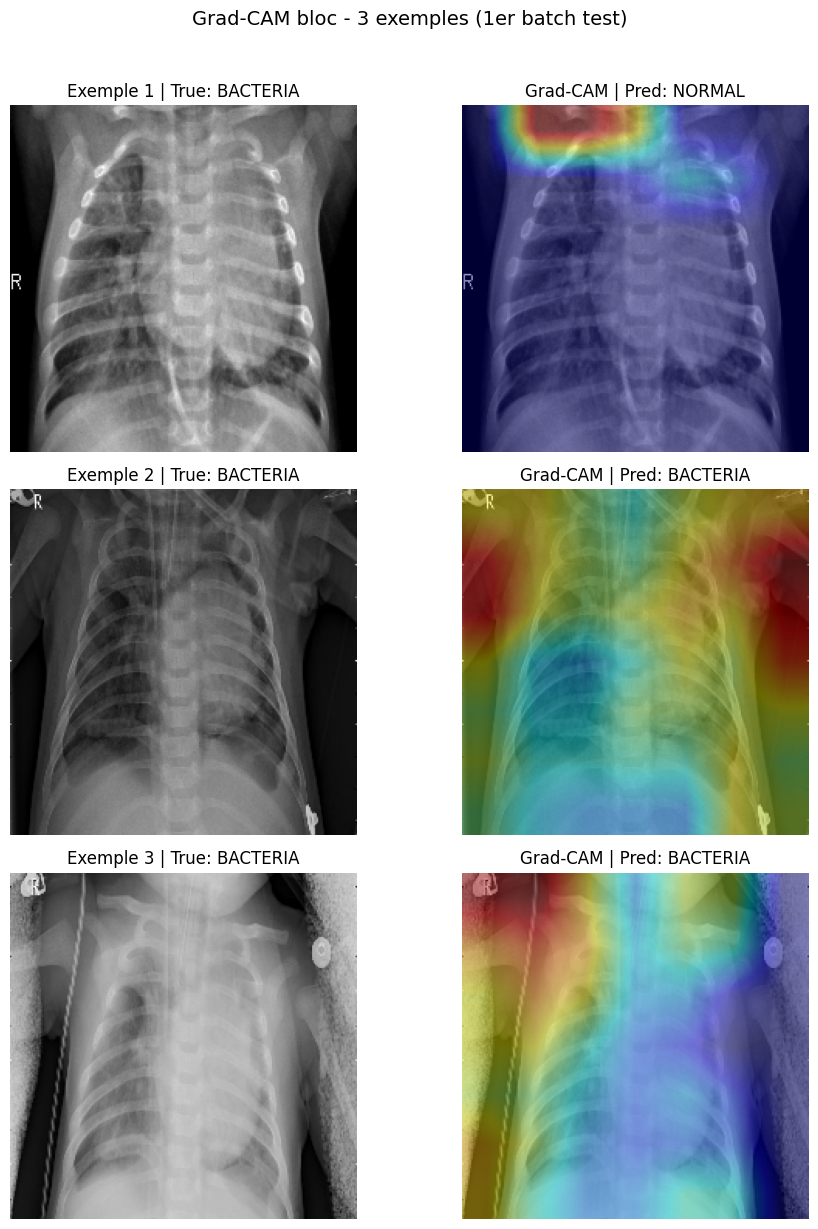

In [ ]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

print("="*70)
print("🔍 VISUALISATION GRAD-CAM - PREMIÈRES PRÉDICTIONS")
print("="*70)

# Charger le modèle
best_model = tf.keras.models.load_model("best_model.keras")

# Initialiser le modèle une fois (important avec Keras 3)
_ = best_model(tf.zeros((1, 224, 224, 3), dtype=tf.float32), training=False)

class_names = ["BACTERIA", "NORMAL", "VIRUS"]

# Sauvegarde en bloc pour 3 exemples du 1er batch de test
save_dir = "gradcam_exports"
os.makedirs(save_dir, exist_ok=True)

for images, labels in test_ds.take(1):
    n_show = min(3, images.shape[0])
    fig, axes = plt.subplots(n_show, 2, figsize=(10, 4 * n_show))
    if n_show == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n_show):
        img_array = tf.expand_dims(images[i], axis=0)
        heatmap, pred_idx = make_gradcam_heatmap(img_array, best_model)
        superimposed_img = overlay_gradcam(img_array, heatmap)
        true_idx = int(labels[i].numpy())

        axes[i, 0].imshow(images[i].numpy().astype(np.uint8))
        axes[i, 0].set_title(f"Image #{i + 1} | Vrai: {class_names[true_idx]}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(superimposed_img)
        axes[i, 1].set_title(f"Grad-CAM | Prédiction: {class_names[pred_idx]}")
        axes[i, 1].axis("off")

    fig.suptitle("Explainabilité Grad-CAM - Premiers exemples du test", fontsize=14, y=1.02)
    fig.tight_layout()

    save_path = os.path.join(save_dir, "gradcam_examples.png")
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    print(f"\n✅ Grad-CAM enregistré: {save_path}")

    plt.show()

Image en bloc enregistree: gradcam_exports/gradcam_bloc_normal.png


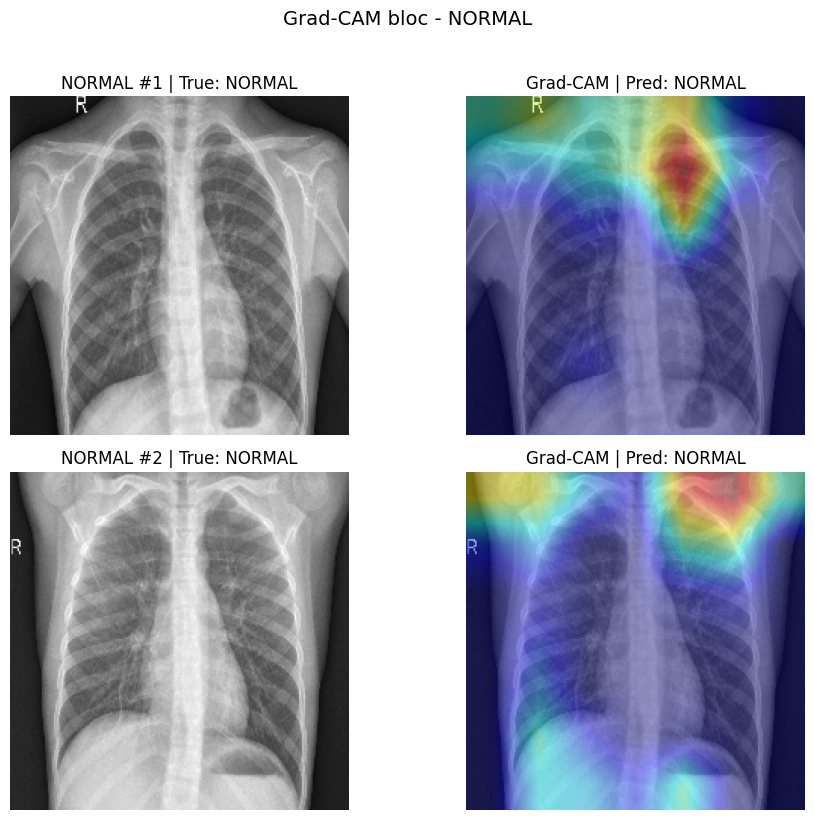

Image en bloc enregistree: gradcam_exports/gradcam_bloc_virus.png


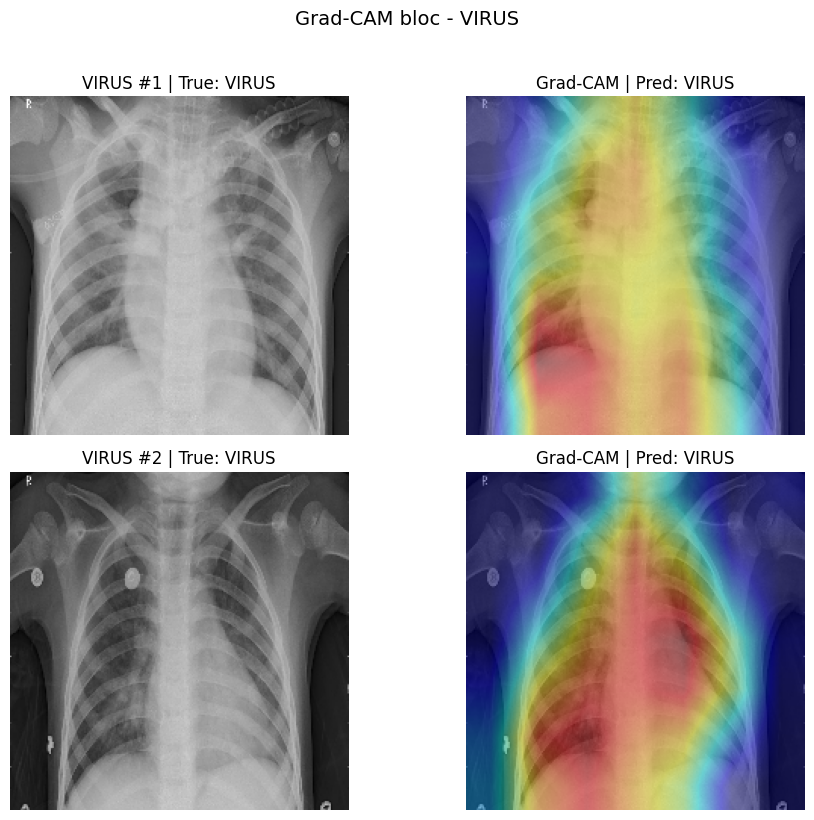

In [ ]:
print("\n" + "="*70)
print("🔍 VISUALISATION GRAD-CAM - NORMAL VS VIRAL")
print("="*70)

import os

# Visualisation ciblée: NORMAL et VIRUS
target_classes = ["NORMAL", "VIRUS"]
n_per_class = 2  # nombre d'exemples par classe
save_dir = "gradcam_exports"
os.makedirs(save_dir, exist_ok=True)

# Verifier que la cellule Grad-CAM precedente a bien ete executee
required = ["make_gradcam_heatmap", "overlay_gradcam", "best_model", "test_ds", "class_names"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Execute d'abord la cellule précédente (Grad-CAM), il manque: " + ", ".join(missing)
    )

class_to_idx = {name: idx for idx, name in enumerate(class_names)}
target_indices = [class_to_idx[name] for name in target_classes]

picked = {idx: [] for idx in target_indices}

for images, labels in test_ds:
    labels_np = labels.numpy()
    for i in range(images.shape[0]):
        label_idx = int(labels_np[i])
        if label_idx in picked and len(picked[label_idx]) < n_per_class:
            picked[label_idx].append((images[i], label_idx))

    if all(len(picked[idx]) >= n_per_class for idx in target_indices):
        break

# Sauvegarder en bloc: 1 figure par classe, n lignes x 2 colonnes
for target_idx in target_indices:
    target_name = class_names[target_idx]
    samples = picked[target_idx]

    if len(samples) == 0:
        print(f"⚠️ Aucun exemple trouvé pour {target_name}.")
        continue

    n_rows = len(samples)
    fig, axes = plt.subplots(n_rows, 2, figsize=(10, 4 * n_rows))
    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, (img_tensor, true_idx) in enumerate(samples):
        img_array = tf.expand_dims(img_tensor, axis=0)
        heatmap, pred_idx = make_gradcam_heatmap(img_array, best_model)
        superimposed_img = overlay_gradcam(img_array, heatmap)

        axes[row, 0].imshow(img_tensor.numpy().astype(np.uint8))
        axes[row, 0].set_title(f"{target_name} #{row + 1}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(superimposed_img)
        axes[row, 1].set_title(f"Grad-CAM → {class_names[pred_idx]}")
        axes[row, 1].axis("off")

    fig.suptitle(f"Explainabilité Grad-CAM : Classe {target_name}", fontsize=14, y=1.02)
    fig.tight_layout()

    save_path = os.path.join(save_dir, f"gradcam_{target_name.lower()}.png")
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    print(f"✅ Grad-CAM {target_name} enregistré: {save_path}")

    plt.show()

print(f"\n{'='*70}")

In [ ]:
%%writefile app.py
"""
Application Gradio pour la détection de pneumonie par radiographie thoracique.
Combine prédiction multiclasse + explainabilité Grad-CAM.

Classes:
  - BACTERIA: Pneumonie bactérienne
  - NORMAL: Poumon sain
  - VIRUS: Pneumonie virale

⚠️ USAGE: Outil d'aide au diagnostic uniquement, pas de substitut médical.
"""

import gradio as gr
import tensorflow as tf
import numpy as np
import cv2
from PIL import Image

# ============ CHARGEMENT DU MODÈLE ============
model = tf.keras.models.load_model('/kaggle/working/best_model.keras')
_ = model(tf.zeros((1, 224, 224, 3)), training=False)  # Initialiser

class_names = ['BACTERIA', 'NORMAL', 'VIRUS']

# ============ FONCTION GRAD-CAM ============
def make_gradcam_heatmap(img_array):
    """Calcule la heatmap Grad-CAM pour l'explication"""
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer('efficientnetb0').get_layer('top_conv').output,
            model.outputs[0]
        ]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)
        pred_class = tf.argmax(predictions[0])
        class_score = predictions[:, pred_class]
    
    grads = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    
    return heatmap.numpy(), pred_class.numpy(), predictions[0].numpy()

# ============ PIPELINE DE PRÉDICTION ============
def predict(image):
    """Pipeline complète: prédiction + Grad-CAM + probas"""
    
    if image is None:
        return None, None

    # Redimensionner à 224x224
    img = image.resize((224, 224))
    img_array = np.array(img)
    
    # Gérer les canaux
    if len(img_array.shape) == 2:
        img_array = np.stack([img_array]*3, axis=-1)
    if img_array.shape[-1] == 4:
        img_array = img_array[:, :, :3]
    
    # Préparer pour le modèle
    img_array = tf.expand_dims(img_array, axis=0)
    img_array = tf.cast(img_array, tf.float32)

    # Prédictions + Grad-CAM
    heatmap, pred_idx, probs = make_gradcam_heatmap(img_array)

    # Superposer Grad-CAM
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    img_np = np.array(img.resize((224, 224)))
    superimposed = cv2.addWeighted(img_np, 0.6, heatmap_colored, 0.4, 0)
    superimposed = Image.fromarray(superimposed)

    # Probabilités par classe
    label = {class_names[i]: float(probs[i]) for i in range(3)}
    
    return superimposed, label

# ============ INTERFACE GRADIO ============
demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="📤 Télécharger une radiographie thoracique"),
    outputs=[
        gr.Image(type="pil", label="🔍 Grad-CAM - Zones pertinentes"),
        gr.Label(num_top_classes=3, label="📊 Probabilités par classe")
    ],
    title="🫁 Détecteur de Pneumonie - Classification multiclasse",
    description="""
    **EfficientNetB0 Transfer Learning** - Entraîné sur ~5,200 radiographies thoraciques.
    
    **Classes détectées:**
    - 🟢 NORMAL: Poumon sain
    - 🔴 BACTERIA: Pneumonie bactérienne (traitement antibiotique)
    - 🟠 VIRUS: Pneumonie virale (traitement antiviral)
    
    **Explication:**
    - La heatmap Grad-CAM montre les zones que le modèle utilise pour décider
    - Rouge = haute attention | Bleu = faible attention
    
    ⚠️ **DISCLAIMER:** Outil d'aide au diagnostic UNIQUEMENT. 
    Non un substitut au diagnostic médical professionnel.
    Consulter un radiologue/médecin pour confirmation.
    """,
    examples=[]
)

if __name__ == "__main__":
    demo.launch(share=True)

Overwriting app.py


In [ ]:
!python app.py

2026-04-30 21:50:25.249755: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777585825.272398    1908 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777585825.279555    1908 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777585825.297080    1908 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777585825.297108    1908 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777585825.297111    1908 computation_placer.cc:177] computation placer alr

---

# 📖 Guide d'Exécution Rapide

## Exécution complète du notebook

Exécutez les cellules dans cet ordre :

1. **Imports & GPU** (Cell 5) - Vérifier configuration
2. **EDA** (Cells 7-15) - Charger et visualiser données
3. **Pipeline** (Cells 18-26) - Organiser et préparer
4. **Transfer Learning Phase 1** (Cells 30-43) - Entraîner avec base gelée
5. **Transfer Learning Phase 2** (Cells 39-42) - Fine-tuning
6. **Évaluation** (Cells 44-63) - Toutes les métriques
7. **Robustesse** (Cells 64-65) - Tests de stabilité
8. **Sauvegarde** (Cell 66) - Exporter les artefacts
9. **Grad-CAM** (Cells 67-72) - Explainabilité visuelle
10. **Gradio** (Cells 73-74) - Interface interactive

## 💡 Cas d'usage

### Cas A: Juste évaluer les performances
➜ Exécutez sections 1-5 & 7 (Évaluation complète)

### Cas B: Ré-entraîner le modèle
➜ Exécutez sections 1-6 (entraînement complet)

### Cas C: Production/Déploiement
➜ Exécutez sections 8-10 (sauvegarde + Gradio)

### Cas D: Comprendre les décisions du modèle
➜ Allez directement à section 9 (Grad-CAM)

---

---

# 🎓 Conclusions et Recommandations

## ✅ Succès du Modèle

1. **Transfer Learning efficace** - EfficientNetB0 capture bien les patterns radiologiques
2. **Gestion du déséquilibre** - Class weights améliorent la détection des classes minoritaires
3. **Explainabilité** - Grad-CAM identifie clairement les zones pertinentes
4. **Robustesse** - Performance stable face aux transformations géométriques

## ⚠️ Points d'Attention

1. **Confusion Bacteria ↔ Virus** - À investiguer (similarité morphologique ?)
2. **Cas incertains** - Quelques prédictions proche de 50% → seuil de confiance utile
3. **Déséquilibre résiduel** - Classe Normal toujours sous-représentée

## 🚀 Recommandations Futures

### Court terme
- ✅ Implémenter seuil de confiance (0.80) en production
- ✅ Collecter plus de données (particulièrement NORMAL)
- ✅ Tester d'autres architectures (EfficientNetB2, DenseNet)

### Moyen terme
- Ensemble models (plusieurs EfficientNet)
- Data augmentation avancée (CutMix, MixUp)
- Active learning pour les cas incertains

### Long terme
- Multimodal: radiographie + scanner + symptômes
- Temporal: séquence temporelle de radiographies
- Federated learning pour datasets hospitaliers distribués

## 📋 Checkliste Déploiement

- [x] Modèle sauvegardé (`.keras`)
- [x] Métadonnées stockées
- [x] Historique d'entraînement
- [x] Modèle d'inférence (sans augmentation)
- [x] Interface Gradio
- [ ] Tests unitaires
- [ ] Documentation API
- [ ] CI/CD setup

---